[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab3-GenAI-LLM/notebooks/03-llm-fundamentals.ipynb)

# Large Language Models (LLM) - Fundamental Concepts

**ELMED219 / BMED365 - Lab 3**

Last updated:<br>
2026-01-02, A. Lundervold

---

## Learning Objectives

After this notebook, you should be able to:
- Understand how LLMs generate text token by token
- Explain what tokens and embeddings are
- Describe how temperature affects text generation
- Understand limitations with context windows

## Contents

1. [Environment Setup](#1-environment-setup)
2. [Tokenization](#2-tokenization)
3. [Temperature and Sampling](#3-temperature-and-sampling)
4. [Context Window](#4-context-window)
5. [Practical Implications](#5-practical-implications)

---

## 1. Environment Setup

In [3]:
import sys
import os

# Check if we're running in Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab")
    !pip install tiktoken --quiet
else:
    print("Running in local environment")

# Standard imports
import numpy as np
import matplotlib.pyplot as plt

# Tokenizer
try:
    import tiktoken
    TIKTOKEN_AVAILABLE = True
    print("tiktoken available")
except ImportError:
    TIKTOKEN_AVAILABLE = False
    print("tiktoken not available - some examples will use simulated data")

print("Environment is configured!")

Running in local environment
tiktoken available
Environment is configured!


---

## 2. Tokenization

### What are tokens?

LLMs don't read text character by character or word by word. They use **tokens** - which are a compromise between the two.

A token can be:
- A whole word: "patient"
- Part of a word: "pat" + "ient"
- Punctuation: ".", ","
- Special characters: spaces, line breaks

### Why tokenization?

1. **Efficiency**: Fewer units to process than individual characters
2. **Flexibility**: Can handle unknown words by breaking them down
3. **Language neutrality**: Same system works for different languages

In [4]:
if TIKTOKEN_AVAILABLE:
    # Use OpenAI's tokenizer (same as GPT-3.5/GPT-4)
    encoding = tiktoken.encoding_for_model("gpt-3.5-turbo")
    
    # Medical example
    text = "The patient has diabetes mellitus type 2 and hypertension."
    tokens = encoding.encode(text)
    token_strings = [encoding.decode([token]) for token in tokens]
    
    print(f"Original text: {text}")
    print(f"Number of tokens: {len(tokens)}")
    print(f"\nTokens:")
    for i, (token, string) in enumerate(zip(tokens, token_strings)):
        print(f"  {i:2d}: '{string}' (ID: {token})")
else:
    print("Simulated tokenization (tiktoken not available):")
    tokens = ["The", " patient", " has", " diabetes", " mell", "itus", 
              " type", " ", "2", " and", " hypert", "ension", "."]
    for i, token in enumerate(tokens):
        print(f"  {i:2d}: '{token}'")

Original text: The patient has diabetes mellitus type 2 and hypertension.
Number of tokens: 12

Tokens:
   0: 'The' (ID: 791)
   1: ' patient' (ID: 8893)
   2: ' has' (ID: 706)
   3: ' diabetes' (ID: 20335)
   4: ' mell' (ID: 54448)
   5: 'itus' (ID: 36891)
   6: ' type' (ID: 955)
   7: ' ' (ID: 220)
   8: '2' (ID: 17)
   9: ' and' (ID: 323)
  10: ' hypertension' (ID: 63308)
  11: '.' (ID: 13)


### Tokenization of medical terms

Medical terms can be tokenized in unexpected ways:

In [5]:
if TIKTOKEN_AVAILABLE:
    medical_terms = [
        "hypertension",
        "myocardial infarction", 
        "gastroesophageal",
        "paracetamol",
        "metoprolol"
    ]
    
    print("How medical terms are tokenized:")
    print("-" * 50)
    
    for term in medical_terms:
        tokens = encoding.encode(term)
        token_strings = [encoding.decode([t]) for t in tokens]
        print(f"{term}")
        print(f"  -> {token_strings} ({len(tokens)} tokens)")
        print()

How medical terms are tokenized:
--------------------------------------------------
hypertension
  -> ['hyp', 'ert', 'ension'] (3 tokens)

myocardial infarction
  -> ['my', 'ocard', 'ial', ' inf', 'ar', 'ction'] (6 tokens)

gastroesophageal
  -> ['g', 'astro', 'es', 'ophage', 'al'] (5 tokens)

paracetamol
  -> ['par', 'acet', 'am', 'ol'] (4 tokens)

metoprolol
  -> ['met', 'op', 'rol', 'ol'] (4 tokens)



### Reflection

> **Note**: Common English words are often one token, while specialized medical terms are often split up. This can affect the model's performance on medical text.

---

## 3. Temperature and Sampling

### What is temperature?

When an LLM generates text, it predicts the probability of each possible next token. **Temperature** controls how "creative" vs. "focused" the model is:

| Temperature | Behavior | Use Case |
|-------------|----------|----------|
| 0.0 | Deterministic - always chooses most probable | Facts, coding |
| 0.3-0.5 | Conservative - predictable | Medical documentation |
| 0.7-1.0 | Balanced - varied | General conversation |
| 1.5-2.0 | Creative - unpredictable | Brainstorming, creative writing |

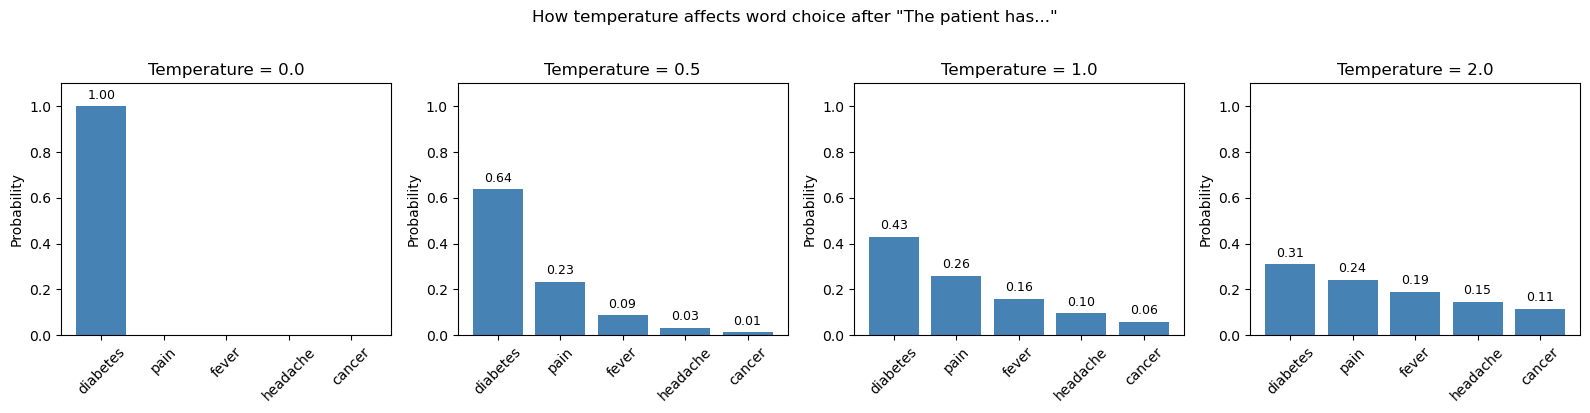

In [7]:
def apply_temperature(logits, temperature):
    """
    Apply temperature to logits and calculate probabilities.
    
    Args:
        logits: Raw model output (log-probabilities)
        temperature: Scaling (0 = deterministic, >1 = more random)
    
    Returns:
        Probability distribution over tokens
    """
    if temperature == 0:
        # Deterministic: put all mass on highest
        probs = np.zeros_like(logits)
        probs[np.argmax(logits)] = 1.0
        return probs
    
    # Scale logits with temperature
    scaled_logits = logits / temperature
    
    # Softmax to get probabilities
    exp_logits = np.exp(scaled_logits - np.max(scaled_logits))  # Numerical stability
    probs = exp_logits / np.sum(exp_logits)
    
    return probs

# Example: Predictions for next word after "The patient has"
possible_words = ["diabetes", "pain", "fever", "headache", "cancer"]
logits = np.array([2.5, 2.0, 1.5, 1.0, 0.5])  # Raw model output

# Visualize the effect of temperature
temperatures = [0.0, 0.5, 1.0, 2.0]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, temp in zip(axes, temperatures):
    probs = apply_temperature(logits, temp)
    bars = ax.bar(possible_words, probs, color='steelblue')
    ax.set_title(f'Temperature = {temp}')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Probability')
    ax.tick_params(axis='x', rotation=45)
    
    # Add values
    for bar, prob in zip(bars, probs):
        if prob > 0.01:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                   f'{prob:.2f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('How temperature affects word choice after "The patient has..."', y=1.02)
plt.tight_layout()
plt.show()

In [8]:
def sample_next_word(probs, words):
    """Sample a word based on probability distribution."""
    idx = np.random.choice(len(words), p=probs)
    return words[idx]

# Demonstrate sampling with different temperatures
print("Generating 5 words with different temperature values:")
print("=" * 60)

np.random.seed(42)  # For reproducibility

for temp in [0.0, 0.5, 1.0, 2.0]:
    probs = apply_temperature(logits, temp)
    samples = [sample_next_word(probs, possible_words) for _ in range(5)]
    print(f"\nTemperature {temp}:")
    print(f"  Generated words: {', '.join(samples)}")
    
    if temp == 0.0:
        print("  -> Always same word (deterministic)")
    elif temp == 0.5:
        print("  -> Favors high-probability words")
    elif temp == 1.0:
        print("  -> Balanced variation")
    else:
        print("  -> More unpredictable, can choose unlikely words")

Generating 5 words with different temperature values:

Temperature 0.0:
  Generated words: diabetes, diabetes, diabetes, diabetes, diabetes
  -> Always same word (deterministic)

Temperature 0.5:
  Generated words: diabetes, diabetes, pain, diabetes, pain
  -> Favors high-probability words

Temperature 1.0:
  Generated words: diabetes, cancer, fever, diabetes, diabetes
  -> Balanced variation

Temperature 2.0:
  Generated words: diabetes, diabetes, pain, pain, diabetes
  -> More unpredictable, can choose unlikely words


### Practical recommendation for medical use

| Task | Recommended temperature |
|------|------------------------|
| Medical record | 0.0 - 0.3 |
| Summary | 0.3 - 0.5 |
| Patient information | 0.5 - 0.7 |
| Brainstorming | 0.8 - 1.2 |

---

## 4. Context Window

### What is a context window?

The context window is the maximum amount of text an LLM can "remember" and process simultaneously. Everything outside this window is unknown to the model.

### Context windows for popular models

| Model | Context Window | Approx. pages of text |
|-------|----------------|----------------------|
| GPT-3.5 | 4,096 tokens | ~5 pages |
| GPT-4 | 8,192 tokens | ~10 pages |
| GPT-4 Turbo | 128,000 tokens | ~160 pages |
| Claude 3 | 200,000 tokens | ~250 pages |

In [9]:
# Typical medical documents and their token estimates
documents = {
    "Short consultation note": 200,
    "Standard medical record": 500,
    "Comprehensive medical history": 2000,
    "Full patient record (1 year)": 10000,
    "Complete patient file (5 years)": 50000,
    "Medical research article": 8000,
}

models = {
    "GPT-3.5": 4096,
    "GPT-4": 8192,
    "GPT-4 Turbo": 128000,
    "Claude 3": 200000,
}

print("Document sizes vs. model capacity:")
print("=" * 70)

for doc, tokens in documents.items():
    print(f"\n{doc} (~{tokens:,} tokens):")
    for model, capacity in models.items():
        if tokens <= capacity:
            utilization = (tokens / capacity) * 100
            print(f"  {model}: OK ({utilization:.0f}% of capacity)")
        else:
            excess = tokens - capacity
            print(f"  {model}: Too large ({excess:,} tokens over)")

Document sizes vs. model capacity:

Short consultation note (~200 tokens):
  GPT-3.5: OK (5% of capacity)
  GPT-4: OK (2% of capacity)
  GPT-4 Turbo: OK (0% of capacity)
  Claude 3: OK (0% of capacity)

Standard medical record (~500 tokens):
  GPT-3.5: OK (12% of capacity)
  GPT-4: OK (6% of capacity)
  GPT-4 Turbo: OK (0% of capacity)
  Claude 3: OK (0% of capacity)

Comprehensive medical history (~2,000 tokens):
  GPT-3.5: OK (49% of capacity)
  GPT-4: OK (24% of capacity)
  GPT-4 Turbo: OK (2% of capacity)
  Claude 3: OK (1% of capacity)

Full patient record (1 year) (~10,000 tokens):
  GPT-3.5: Too large (5,904 tokens over)
  GPT-4: Too large (1,808 tokens over)
  GPT-4 Turbo: OK (8% of capacity)
  Claude 3: OK (5% of capacity)

Complete patient file (5 years) (~50,000 tokens):
  GPT-3.5: Too large (45,904 tokens over)
  GPT-4: Too large (41,808 tokens over)
  GPT-4 Turbo: OK (39% of capacity)
  Claude 3: OK (25% of capacity)

Medical research article (~8,000 tokens):
  GPT-3.5: To

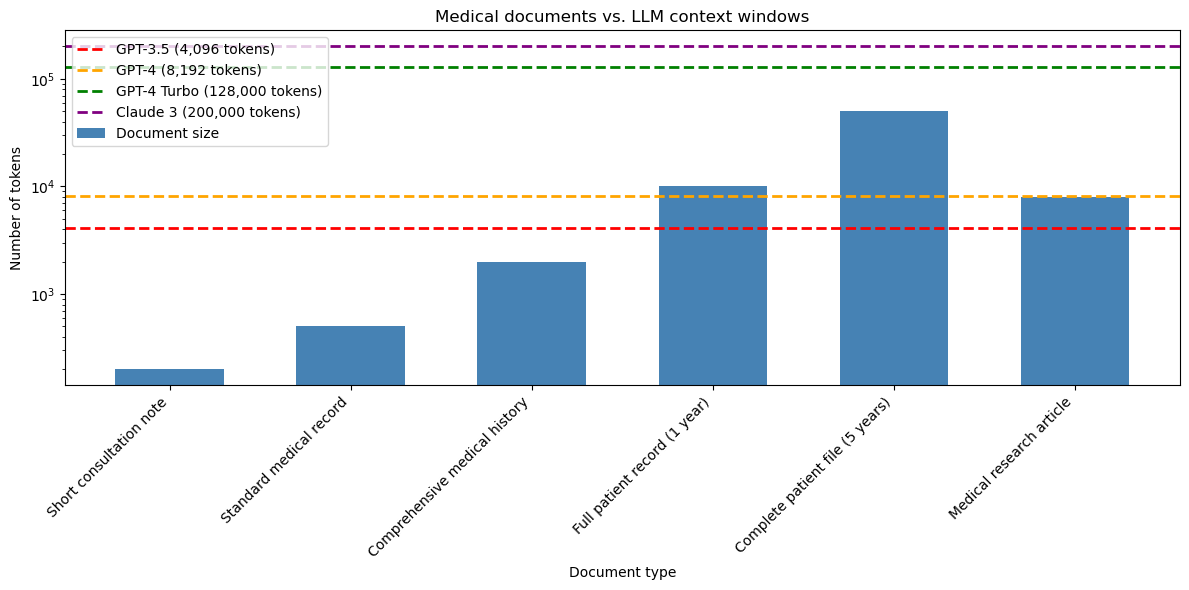

In [10]:
# Visualization
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(documents))
width = 0.6

bars = ax.bar(x, list(documents.values()), width, color='steelblue', label='Document size')

# Add horizontal lines for model capacity
colors = ['red', 'orange', 'green', 'purple']
for (model, capacity), color in zip(models.items(), colors):
    ax.axhline(y=capacity, color=color, linestyle='--', linewidth=2, label=f'{model} ({capacity:,} tokens)')

ax.set_xlabel('Document type')
ax.set_ylabel('Number of tokens')
ax.set_title('Medical documents vs. LLM context windows')
ax.set_xticks(x)
ax.set_xticklabels(list(documents.keys()), rotation=45, ha='right')
ax.legend(loc='upper left')
ax.set_yscale('log')

plt.tight_layout()
plt.show()

---

## 5. Practical Implications

### Strategies for long documents

When documents exceed the context window, several strategies exist:

1. **Chunking**
   - Split the document into smaller pieces
   - Process each piece separately
   - Combine the results

2. **Summarization**
   - Create a summary of the document first
   - Use the summary for further analysis

3. **Retrieval-Augmented Generation (RAG)**
   - Index the document in a database
   - Retrieve only relevant parts based on the question
   - Combine with LLM for answers

4. **Prioritization**
   - Identify most relevant information
   - Omit less important parts

In [11]:
# Example: Estimate tokens in a medical record

example_medical_record = """
Patient: 65 year old man
Referral: Investigation of chest pain

History:
Patient has had recurring chest pain for the last 3 months.
Pain is located substernally, radiates to left arm.
Triggered by exertion, improves with rest.
No known heart disease in family.
Smokes 20 cigarettes daily for 40 years.

Status:
General condition good, no dyspnea at rest.
BP: 150/95, Pulse: 75/min regular
Heart auscultation: Normal sounds, no murmurs
Lungs: Normal breath sounds

Additional examinations:
ECG: Normal sinus rhythm, no ST changes
Troponin: <0.01 (normal)
Cholesterol: 6.8 mmol/L (high)

Assessment:
Probable stable angina pectoris
Cardiovascular risk factors: Smoking, hypertension, hypercholesterolemia

Plan:
1. Stress ECG to confirm diagnosis
2. Echocardiography
3. Lifestyle advice: smoking cessation, diet changes
4. Medication: ASA 75mg, statin
5. Follow-up in 3 months
"""

if TIKTOKEN_AVAILABLE:
    tokens = encoding.encode(example_medical_record)
    print(f"Example medical record:")
    print(f"  Number of characters: {len(example_medical_record):,}")
    print(f"  Number of tokens: {len(tokens):,}")
    print(f"  Characters per token: {len(example_medical_record)/len(tokens):.1f}")
    print(f"\nFits in all modern LLMs")
else:
    # Estimate: ~4 characters per token for English text
    est_tokens = len(example_medical_record) // 4
    print(f"Estimated number of tokens: ~{est_tokens}")

Example medical record:
  Number of characters: 877
  Number of tokens: 239
  Characters per token: 3.7

Fits in all modern LLMs


---

## Summary

### Key Points

1. **Tokens** are the basic unit LLMs use - usually word parts or whole words
2. **Medical terms** are often tokenized into multiple tokens (important for cost and performance)
3. **Temperature** controls creativity - use low for medical documentation
4. **Context window** limits how much text the model can process simultaneously
5. **Strategies** like chunking and RAG can handle long documents

### Reflection Questions

1. Why do you think specialized terms are often tokenized into more tokens than common words?
2. In which clinical situations would you use high vs. low temperature?
3. How would you handle a patient with 20 years of medical history?

---

*Next notebook: [04 - Prompt Engineering](04-prompt-engineering.ipynb)*